In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)


# Parte 1
1-Contagem de usuários por plano

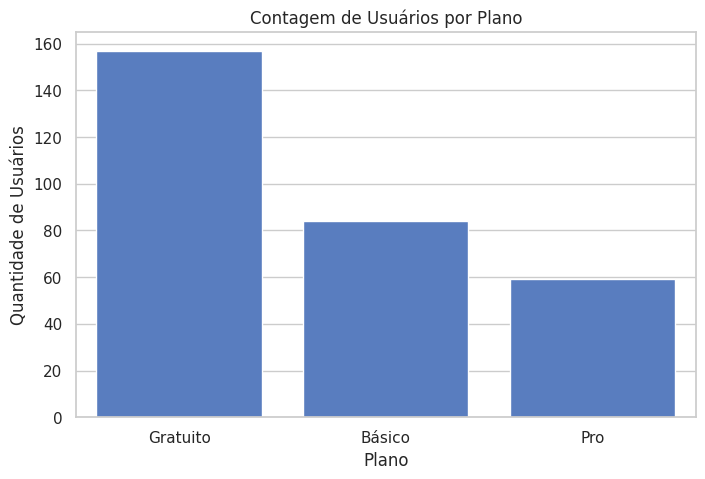

In [2]:
ordem_planos = df_sistema['plano'].value_counts().index

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_sistema,
    x='plano',
    order=ordem_planos
)

plt.title('Contagem de Usuários por Plano')
plt.xlabel('Plano')
plt.ylabel('Quantidade de Usuários')

plt.show()

2-Distribuição das idades com KDE

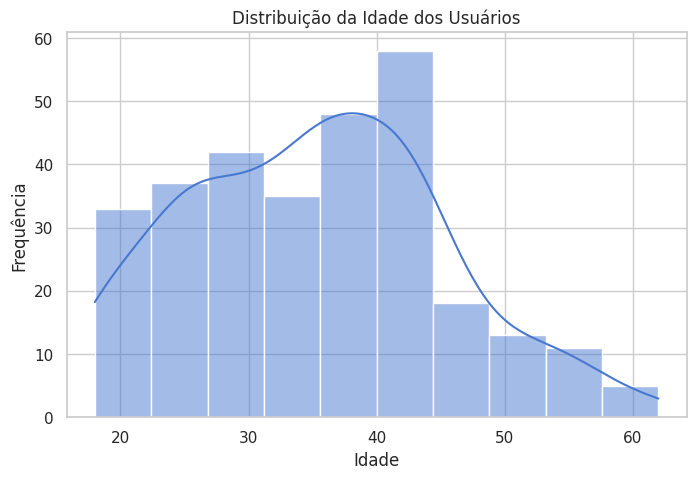

In [3]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_sistema,
    x='idade',
    kde=True
)

plt.title('Distribuição da Idade dos Usuários')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.show()

# Parte 2
3-Boxplot do tempo de uso por plano

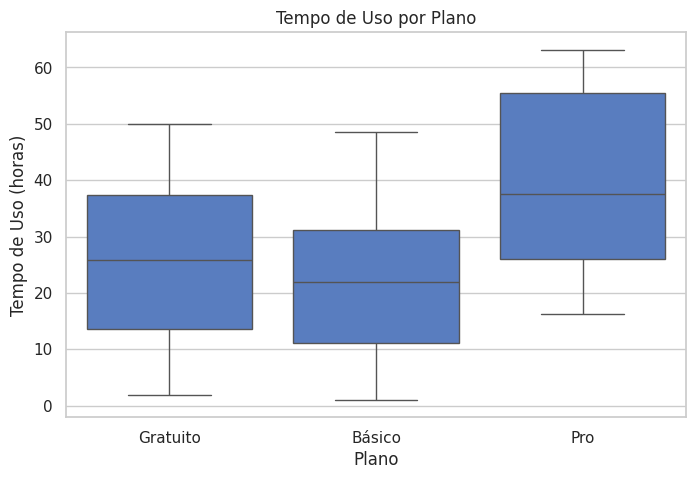

In [4]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_sistema,
    x='plano',
    y='tempo_uso_horas'
)

plt.title('Tempo de Uso por Plano')
plt.xlabel('Plano')
plt.ylabel('Tempo de Uso (horas)')

plt.show()

4-Violinplot de satisfação por plano

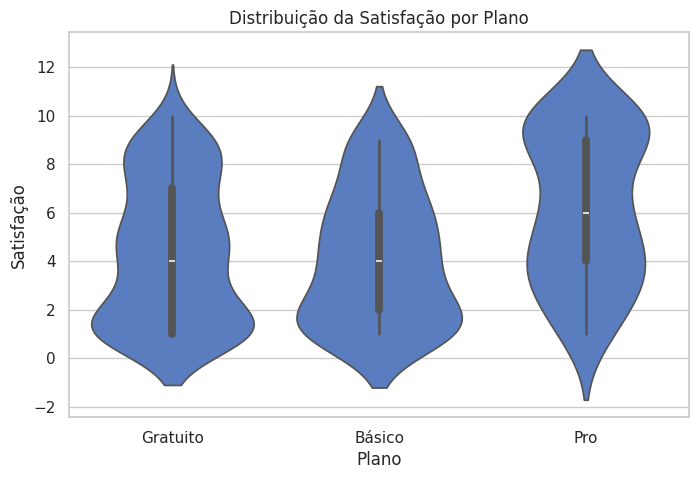

In [5]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df_sistema,
    x='plano',
    y='satisfacao'
)

plt.title('Distribuição da Satisfação por Plano')
plt.xlabel('Plano')
plt.ylabel('Satisfação')

plt.show()

# Parte 3
5-Scatterplot: tempo de uso × satisfação

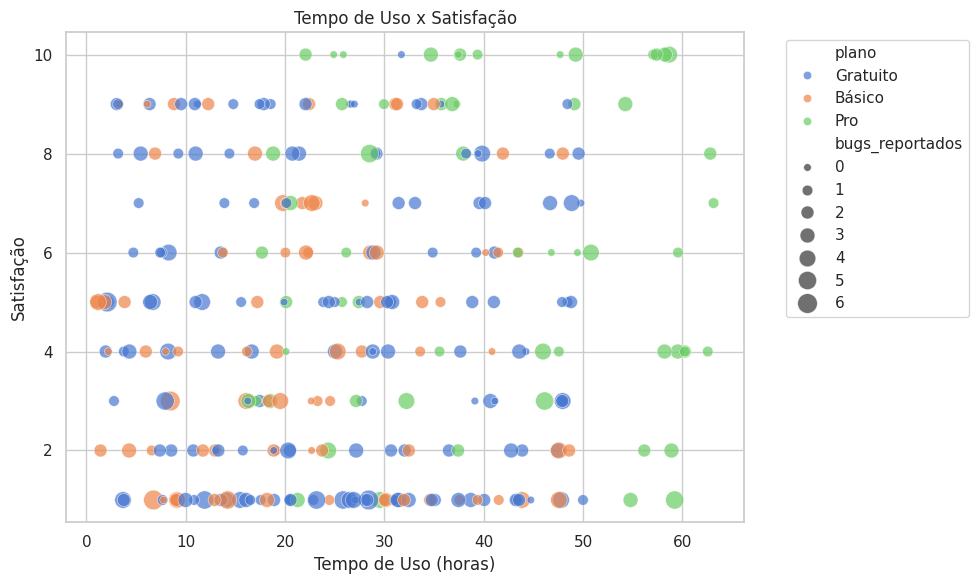

In [8]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_sistema,
    x='tempo_uso_horas',
    y='satisfacao',
    hue='plano',
    size='bugs_reportados',
    sizes=(30, 200),
    alpha=0.7
)

plt.title('Tempo de Uso x Satisfação')
plt.xlabel('Tempo de Uso (horas)')
plt.ylabel('Satisfação')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

6-Matriz de correlação com Heatmap

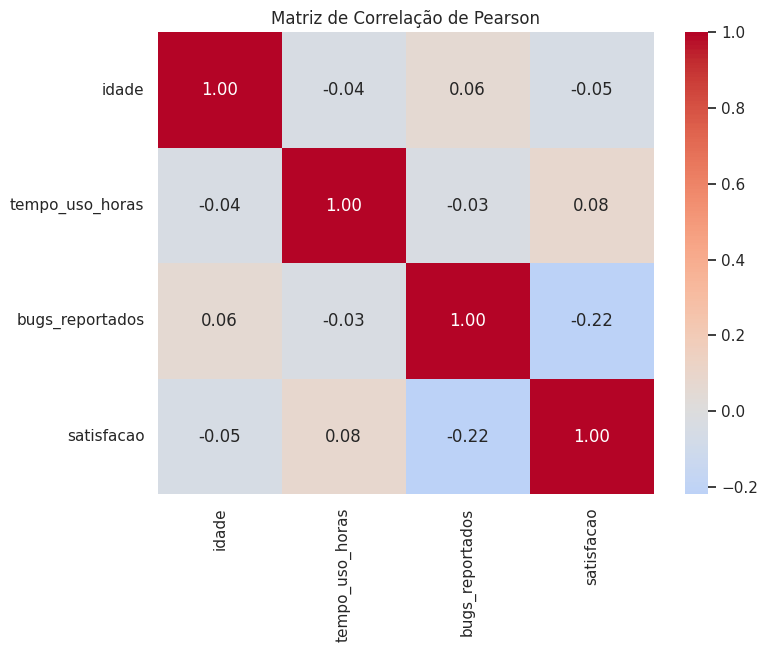

In [9]:
variaveis_numericas = df_sistema.select_dtypes(include=np.number)

correlacao = variaveis_numericas.corr(method='pearson')

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Matriz de Correlação de Pearson')

plt.show()

7-Bônus: Pairplot

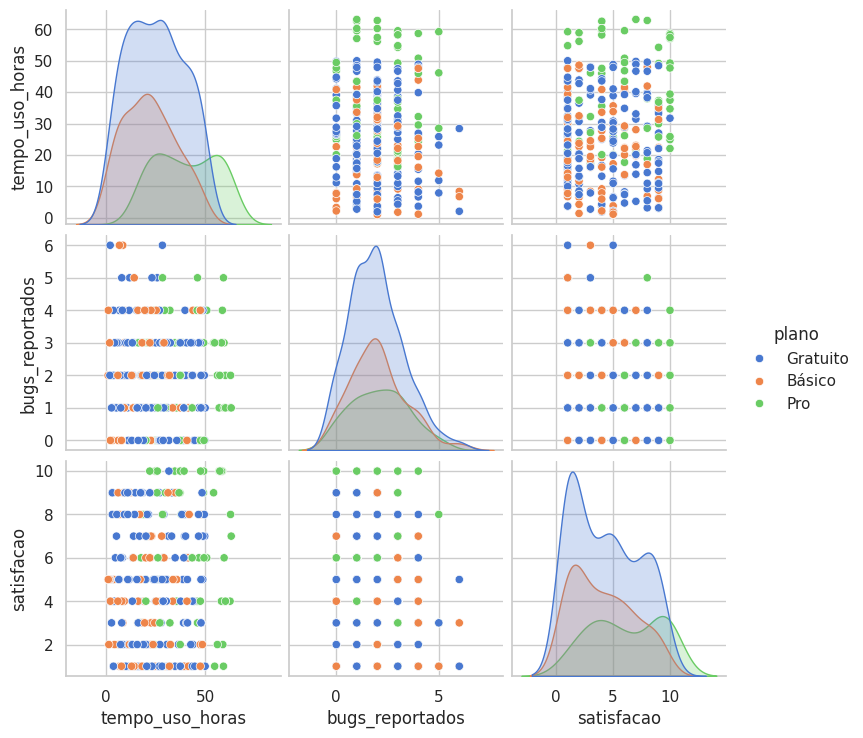

In [10]:
sns.pairplot(
    data=df_sistema,
    vars=[
        'tempo_uso_horas',
        'bugs_reportados',
        'satisfacao'
    ],
    hue='plano'
)

plt.show()